In [6]:
from google.colab import drive
drive.mount("/content/drive")

import tensorflow as tf
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

model_paths = [
    "/content/drive/MyDrive/proyecto_patrones_MIV/XRAY/Modelos_Finales/resultados_EficcientNetB0_batch32_ROC_modelo_final/modelo_EfficientNetB0_final.keras",
    "/content/drive/MyDrive/proyecto_patrones_MIV/XRAY/Modelos_Finales/MobileNetV2_batch32_modelo_final/modelo_MobileNetV2_transfer_final.keras",
    "/content/drive/MyDrive/proyecto_patrones_MIV/XRAY/Modelos_Finales/Densenet121_batch32_modelo_final/modelo_densenet121_final_batch_32_f_cambiado.keras",
]

# Verificar que existan los modelos
for path in model_paths:
    print(Path(path).name, "existe:", Path(path).exists())

rows = []



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
modelo_EfficientNetB0_final.keras existe: True
modelo_MobileNetV2_transfer_final.keras existe: True
modelo_densenet121_final_batch_32_f_cambiado.keras existe: True


In [7]:
# ============================================================
# 1. Crear test_ds
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TEST_DIR = Path("/content/drive/MyDrive/proyecto_patrones_MIV/XRAY/test")
# Cambia esta ruta si tu carpeta test está en otro lado

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Clases detectadas:", test_ds.class_names)
print("IMPORTANTE: normalmente debe ser ['NORMAL', 'PNEUMONIA']")

Found 624 files belonging to 2 classes.
Clases detectadas: ['NORMAL', 'PNEUMONIA']
IMPORTANTE: normalmente debe ser ['NORMAL', 'PNEUMONIA']



Evaluando: modelo_EfficientNetB0_final
20/20 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step

Evaluando: modelo_MobileNetV2_transfer_final
20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step

Evaluando: modelo_densenet121_final_batch_32_f_cambiado
20/20 ━━━━━━━━━━━━━━━━━━━━ 130s 6s/step


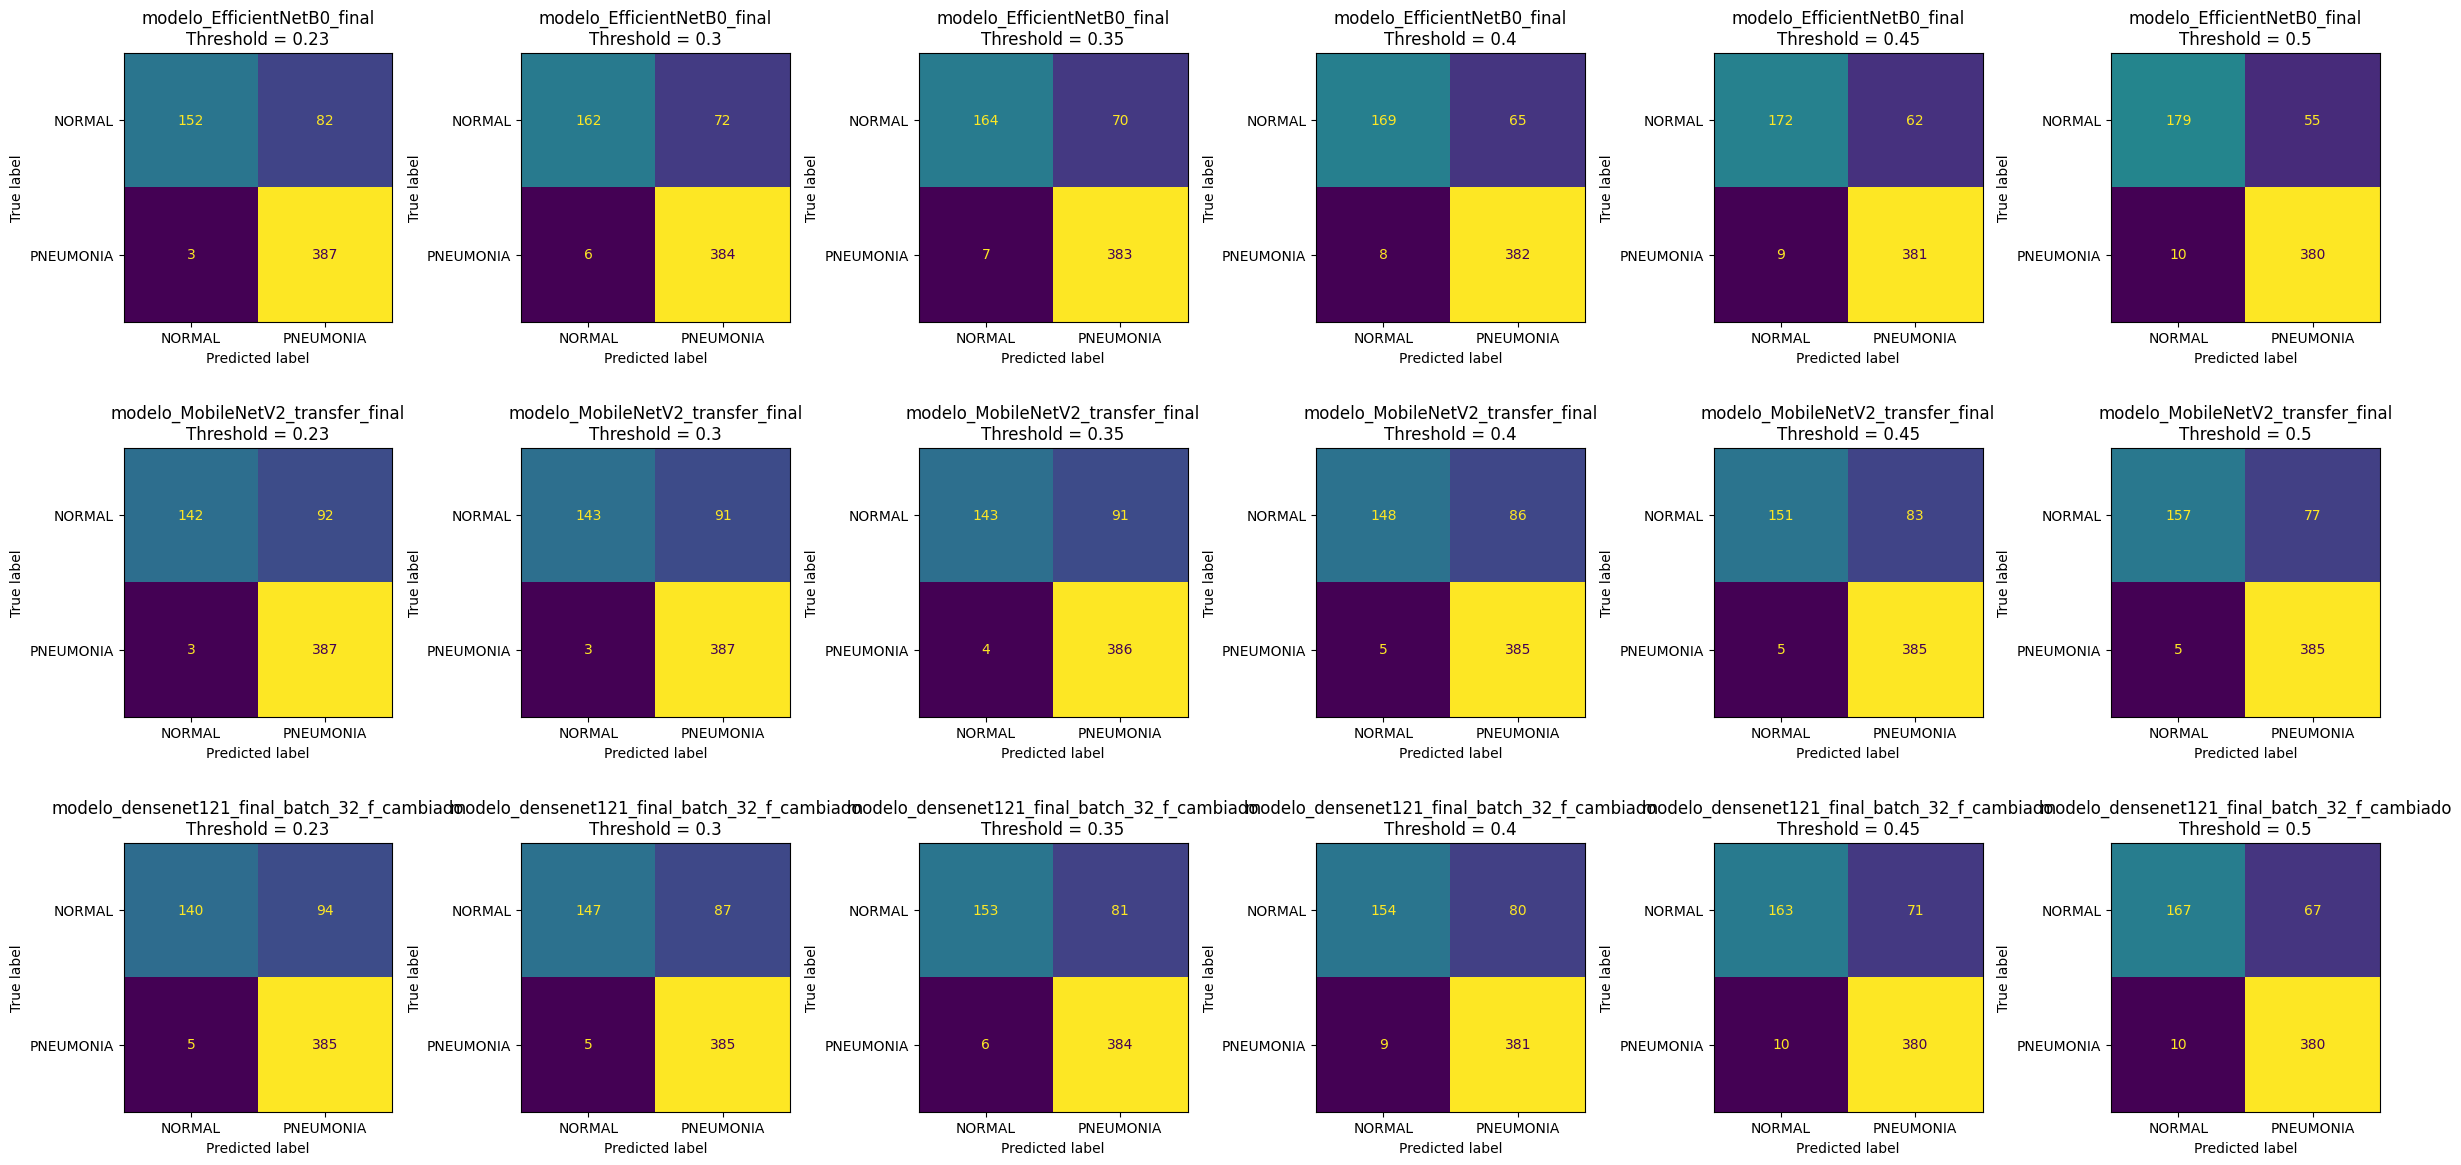

,model,threshold,accuracy,sensitivity,specificity,precision,recall,f1,auc,FN,FP,TP,TN
0,modelo_EfficientNetB0_final,0.23,0.863782,0.992308,0.649573,0.825160,0.992308,0.901048,0.967050,3,82,387,152
1,modelo_EfficientNetB0_final,0.30,0.875000,0.984615,0.692308,0.842105,0.984615,0.907801,0.967050,6,72,384,162
2,modelo_EfficientNetB0_final,0.35,0.876603,0.982051,0.700855,0.845475,0.982051,0.908660,0.967050,7,70,383,164
3,modelo_EfficientNetB0_final,0.40,0.883013,0.979487,0.722222,0.854586,0.979487,0.912784,0.967050,8,65,382,169
4,modelo_EfficientNetB0_final,0.45,0.886218,0.976923,0.735043,0.860045,0.976923,0.914766,0.967050,9,62,381,172
5,modelo_EfficientNetB0_final,0.50,0.895833,0.974359,0.764957,0.873563,0.974359,0.921212,0.967050,10,55,380,179
6,modelo_MobileNetV2_transfer_final,0.23,0.847756,0.992308,0.606838,0.807933,0.992308,0.890679,0.962125,3,92,387,142
7,modelo_MobileNetV2_transfer_final,0.30,0.849359,0.992308,0.611111,0.809623,0.992308,0.891705,0.962125,3,91,387,143
8,modelo_MobileNetV2_transfer_final,0.35,0.847756,0.989744,0.611111,0.809224,0.989744,0.890427,0.962125,4,91,386,143
9,modelo_MobileNetV2_transfer_final,0.40,0.854167,0.987179,0.632479,0.817410,0.987179,0.894309,0.962125,5,86,385,148


In [9]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

thresholds_to_test = [0.23, 0.30, 0.35, 0.40, 0.45, 0.50]

rows = []

# Etiquetas reales del test
y_true = np.concatenate([y.numpy().ravel() for x, y in test_ds]).astype(int)

# Crear figura para matrices de confusión
fig, axes = plt.subplots(
    nrows=len(model_paths),
    ncols=len(thresholds_to_test),
    figsize=(4 * len(thresholds_to_test), 4 * len(model_paths))
)

# Por si solo hay un modelo
if len(model_paths) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, model_path in enumerate(model_paths):
    model_name = Path(model_path).stem
    print("\nEvaluando:", model_name)

    lower_path = model_path.lower()

    if "efficientnet" in lower_path:
        custom_objects = {"preprocess_input": efficientnet_preprocess}

    elif "mobilenet" in lower_path:
        custom_objects = {"preprocess_input": mobilenet_preprocess}

    elif "densenet" in lower_path:
        custom_objects = {"preprocess_input": densenet_preprocess}

    else:
        custom_objects = None

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
        custom_objects=custom_objects,
        safe_mode=False
    )

    # Probabilidades del modelo actual
    y_prob = model.predict(test_ds, verbose=1).ravel()

    # AUC no depende del threshold
    auc_score = roc_auc_score(y_true, y_prob)

    # Probar thresholds para este modelo
    for col_idx, th in enumerate(thresholds_to_test):
        y_pred_th = (y_prob >= th).astype(int)

        cm = confusion_matrix(y_true, y_pred_th, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        precision = precision_score(y_true, y_pred_th, zero_division=0)
        recall = recall_score(y_true, y_pred_th, zero_division=0)
        f1 = f1_score(y_true, y_pred_th, zero_division=0)
        accuracy = accuracy_score(y_true, y_pred_th)

        rows.append({
            "model": model_name,
            "threshold": th,
            "accuracy": accuracy,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "auc": auc_score,
            "FN": fn,
            "FP": fp,
            "TP": tp,
            "TN": tn
        })

        # Mostrar matriz de confusión en la grilla
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["NORMAL", "PNEUMONIA"]
        )

        ax = axes[row_idx, col_idx]

        disp.plot(
            ax=ax,
            values_format="d",
            colorbar=False
        )

        ax.set_title(
            f"{model_name}\nThreshold = {th}"
        )

plt.tight_layout()
plt.show()

threshold_df = pd.DataFrame(rows)
display(threshold_df)